In [1]:
import pandas as pd
df = pd.DataFrame()
df = pd.read_csv("D:/Data_Analysis/DA_portfolio/supermarket_sales.csv")
df.head()

,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8


In [2]:
df.describe()

,Unit_Price,Quantity,Tax,Total,Rating
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000
mean,55.258490,5.0330,5.512745,259.640345,6.957600
std,25.813536,2.6087,2.582829,138.930861,1.730534
min,10.010000,1.0000,1.000000,20.370000,4.000000
25%,33.615000,3.0000,3.317500,137.872500,5.400000
50%,55.610000,5.0000,5.440000,258.040000,6.950000
75%,77.500000,7.0000,7.742500,386.937500,8.400000
max,99.920000,9.0000,10.000000,499.910000,10.000000


In [3]:
df.shape

(2000, 14)

In [4]:
df.size

28000

In [7]:
df.dtypes

Invoice_ID           str
Branch               str
City                 str
Customer_Type        str
Gender               str
Product_Line         str
Unit_Price       float64
Quantity           int64
Tax              float64
Total            float64
Date                 str
Time                 str
Payment              str
Rating           float64
dtype: object

In [32]:
# Cleaning the Dataset remove the duplicate or null values.
df.isnull().sum() # In that no null values but, if null values are find so delete them uesd [ df=df.dropna()]

Invoice_ID       0
Branch           0
City             0
Customer_Type    0
Gender           0
Product_Line     0
Unit_Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64

In [8]:
df.columns.tolist()

['Invoice_ID',
 'Branch',
 'City',
 'Customer_Type',
 'Gender',
 'Product_Line',
 'Unit_Price',
 'Quantity',
 'Tax',
 'Total',
 'Date',
 'Time',
 'Payment',
 'Rating']

In [9]:
#Convert Date Column to Datetime
#In this dataset, the Date column is usually string format.

df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)


datetime64[us]


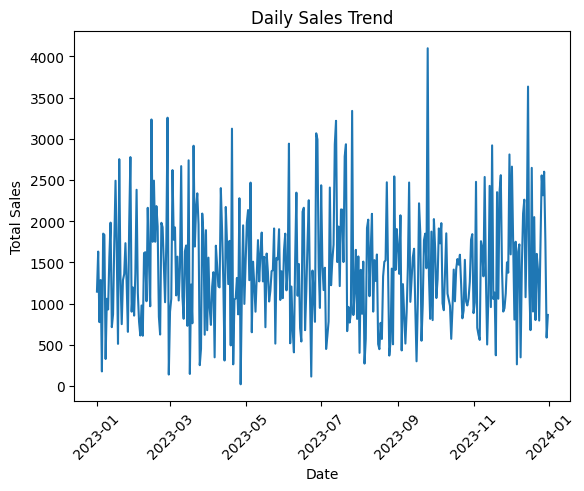

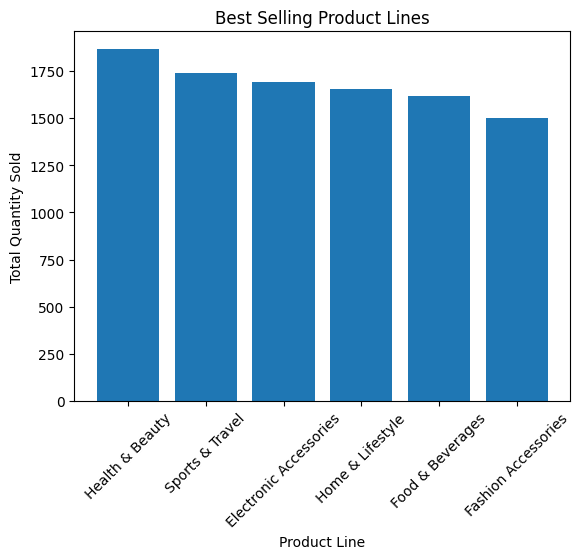

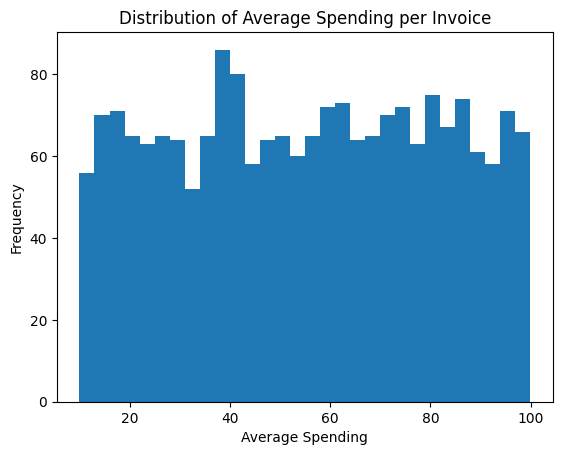

In [10]:
#================================== Analysis of sales================================================#

import matplotlib.pyplot as plt

def analyze_sales(df):
    daily_sales = df.groupby('Date')['Total'].sum() # Daily sales

    #Best product
    best_product = df.groupby('Product_Line')['Quantity'].sum().sort_values(ascending=False)

    # Customer spending patterns
    avg_spending = df.groupby("Invoice_ID")["Unit_Price"].mean()

    return daily_sales ,based_product,avg_spending



daily_sales ,based_product,avg_spending = analyze_sales(df)

#line plot for Daily sales
plt.figure()

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()


#Bar plot for Product sales
plt.figure()

plt.bar(based_product.index, based_product.values)

plt.title("Best Selling Product Lines")
plt.xlabel("Product Line")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)

plt.show()



#Histrogram plot for Average Spending
plt.figure()

plt.hist(avg_spending, bins=30)

plt.title("Distribution of Average Spending per Invoice")
plt.xlabel("Average Spending")
plt.ylabel("Frequency")

plt.show()

